<a href="https://colab.research.google.com/github/Pavithra-M-sece/Data_Science_SAT/blob/main/SEM_5_CIA1_SAT_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ROUND II**

A Recruitment Platform wants to determine which applicant characteristics are associated with being shortlisted for an interview

-- load the applicant records using python pandas

-- handle incomplete resume fields and duplicate applications

-- compare shortlisting rates by experience, education, and skill-match score through EDA

-- calculate a skill-match percentage and create experience bands

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Q16_recruitment.csv")

# Display first 5 records
print("First 5 Records:")
display(df.head())

# Display dataset information
print("\nDataset Information:")
df.info()

First 5 Records:


,application_id,experience_years,education,skill_match_score,shortlisted
0,AP0001,5.5,PhD,76.1,Yes
1,AP0002,12.8,UG,92.6,Yes
2,AP0003,10.4,PG,67.2,Yes
3,AP0004,4.4,PG,57.3,No
4,AP0005,3.4,PG,47.0,No



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   application_id     123 non-null    object 
 1   experience_years   122 non-null    float64
 2   education          123 non-null    object 
 3   skill_match_score  123 non-null    float64
 4   shortlisted        121 non-null    object 
dtypes: float64(2), object(3)
memory usage: 4.9+ KB


In [8]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# Check duplicate application IDs
print("\nDuplicate Application IDs:")
print(df["application_id"].duplicated().sum())

Missing Values:
application_id       0
experience_years     1
education            0
skill_match_score    0
shortlisted          2
dtype: int64

Number of Duplicate Rows:
3

Duplicate Application IDs:
3


In [9]:
# Remove duplicate applications
df = df.drop_duplicates(subset="application_id", keep="first")

# Fill missing experience with median
df["experience_years"] = df["experience_years"].fillna(
    df["experience_years"].median()
)

# Remove records where shortlisted status is missing
df = df.dropna(subset=["shortlisted"])

print("Missing Values After Cleaning:")
print(df.isnull().sum())

print("\nShape After Cleaning:")
print(df.shape)

Missing Values After Cleaning:
application_id       0
experience_years     0
education            0
skill_match_score    0
shortlisted          0
dtype: int64

Shape After Cleaning:
(118, 5)


In [10]:
# Calculate skill match percentage
df["skill_match_percentage"] = df["skill_match_score"]

print("Skill Match Percentage:")
display(
    df[
        ["application_id",
         "skill_match_score",
         "skill_match_percentage"]
    ].head(10)
)

Skill Match Percentage:


,application_id,skill_match_score,skill_match_percentage
0,AP0001,76.1,76.1
1,AP0002,92.6,92.6
2,AP0003,67.2,67.2
3,AP0004,57.3,57.3
4,AP0005,47.0,47.0
5,AP0006,53.6,53.6
6,AP0007,81.3,81.3
7,AP0008,79.0,79.0
8,AP0009,82.9,82.9
9,AP0010,80.4,80.4


In [11]:
# Create experience bands
bins = [0, 2, 5, 10, float("inf")]

labels = [
    "0-2 Years",
    "3-5 Years",
    "6-10 Years",
    "10+ Years"
]

df["experience_band"] = pd.cut(
    df["experience_years"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("Experience Bands:")
display(
    df[
        ["application_id",
         "experience_years",
         "experience_band"]
    ].head(10)
)

print("\nNumber of Applicants in Each Experience Band:")
print(df["experience_band"].value_counts().sort_index())

Experience Bands:


,application_id,experience_years,experience_band
0,AP0001,5.5,6-10 Years
1,AP0002,12.8,10+ Years
2,AP0003,10.4,10+ Years
3,AP0004,4.4,3-5 Years
4,AP0005,3.4,3-5 Years
5,AP0006,6.5,6-10 Years
6,AP0007,8.4,6-10 Years
7,AP0008,7.6,6-10 Years
8,AP0009,14.6,10+ Years
9,AP0010,4.1,3-5 Years



Number of Applicants in Each Experience Band:
experience_band
0-2 Years     20
3-5 Years     27
6-10 Years    35
10+ Years     36
Name: count, dtype: int64


In [12]:
# Convert Yes/No into 1/0
df["shortlisted_numeric"] = df["shortlisted"].map({
    "Yes": 1,
    "No": 0
})

print(df[
    ["application_id",
     "shortlisted",
     "shortlisted_numeric"]
].head(10))

  application_id shortlisted  shortlisted_numeric
0         AP0001         Yes                    1
1         AP0002         Yes                    1
2         AP0003         Yes                    1
3         AP0004          No                    0
4         AP0005          No                    0
5         AP0006          No                    0
6         AP0007          No                    0
7         AP0008         Yes                    1
8         AP0009         Yes                    1
9         AP0010         Yes                    1


In [13]:
# Shortlisting rate by experience band
experience_rate = (
    df.groupby("experience_band", observed=False)
      ["shortlisted_numeric"]
      .mean() * 100
)

print("Shortlisting Rate by Experience:")
print(experience_rate.round(2))

Shortlisting Rate by Experience:
experience_band
0-2 Years     40.00
3-5 Years     33.33
6-10 Years    54.29
10+ Years     72.22
Name: shortlisted_numeric, dtype: float64


In [14]:
# Shortlisting rate by education
education_rate = (
    df.groupby("education")["shortlisted_numeric"]
      .mean() * 100
)

print("Shortlisting Rate by Education:")
print(education_rate.round(2))

Shortlisting Rate by Education:
education
Diploma    37.93
PG         58.33
PhD        65.22
UG         50.00
Name: shortlisted_numeric, dtype: float64


In [15]:
# Create skill-match bands
skill_bins = [0, 50, 70, 85, 100]

skill_labels = [
    "0-50%",
    "51-70%",
    "71-85%",
    "86-100%"
]

df["skill_band"] = pd.cut(
    df["skill_match_percentage"],
    bins=skill_bins,
    labels=skill_labels,
    include_lowest=True
)

print("Skill Match Bands:")
display(
    df[
        ["application_id",
         "skill_match_percentage",
         "skill_band"]
    ].head(10)
)

Skill Match Bands:


,application_id,skill_match_percentage,skill_band
0,AP0001,76.1,71-85%
1,AP0002,92.6,86-100%
2,AP0003,67.2,51-70%
3,AP0004,57.3,51-70%
4,AP0005,47.0,0-50%
5,AP0006,53.6,51-70%
6,AP0007,81.3,71-85%
7,AP0008,79.0,71-85%
8,AP0009,82.9,71-85%
9,AP0010,80.4,71-85%


In [16]:
# Shortlisting rate by skill-match band
skill_rate = (
    df.groupby("skill_band", observed=False)
      ["shortlisted_numeric"]
      .mean() * 100
)

print("Shortlisting Rate by Skill Match:")
print(skill_rate.round(2))

Shortlisting Rate by Skill Match:
skill_band
0-50%        0.00
51-70%      27.27
71-85%      70.59
86-100%    100.00
Name: shortlisted_numeric, dtype: float64


**Round II**

-- uses a scatter plot and bar chart to illustrate the relationships

--summarize the attributes that appear most closely associated with shortlisting.

--prepare a short briefing for the recruitment team based on the findings.

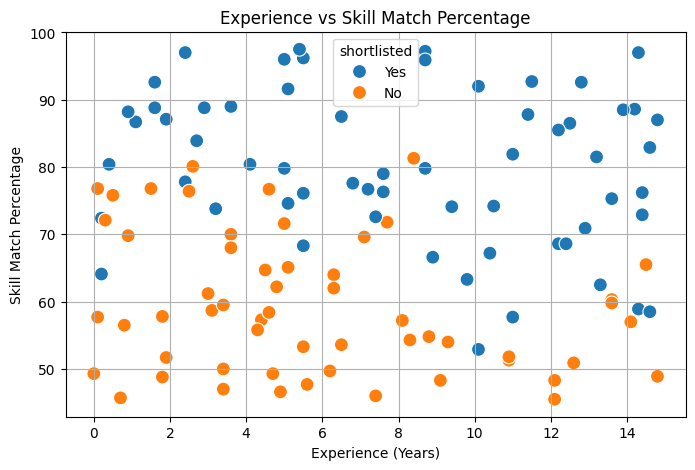

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="experience_years",
    y="skill_match_percentage",
    hue="shortlisted",
    s=100
)

plt.title("Experience vs Skill Match Percentage")
plt.xlabel("Experience (Years)")
plt.ylabel("Skill Match Percentage")
plt.grid(True)

plt.show()

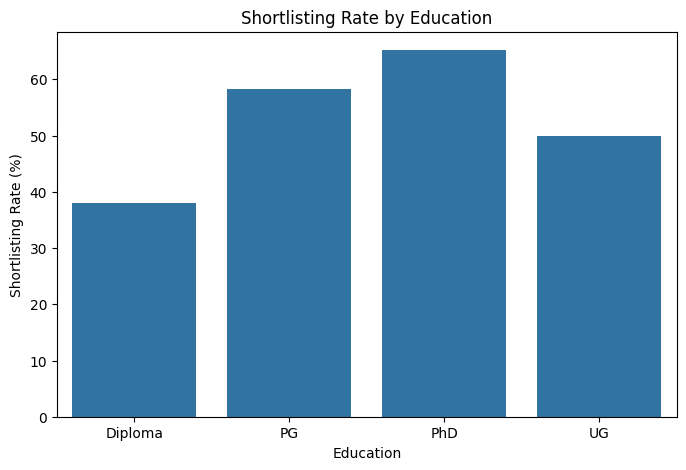

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=education_rate.index,
    y=education_rate.values
)

plt.title("Shortlisting Rate by Education")
plt.xlabel("Education")
plt.ylabel("Shortlisting Rate (%)")

plt.show()

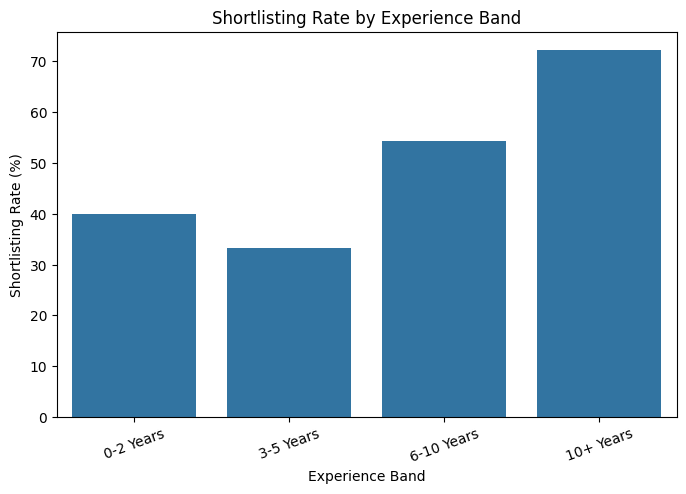

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=experience_rate.index,
    y=experience_rate.values
)

plt.title("Shortlisting Rate by Experience Band")
plt.xlabel("Experience Band")
plt.ylabel("Shortlisting Rate (%)")

plt.xticks(rotation=20)

plt.show()

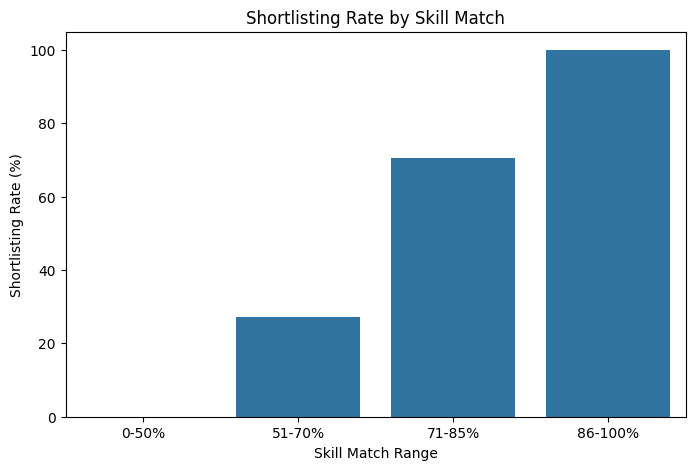

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=skill_rate.index,
    y=skill_rate.values
)

plt.title("Shortlisting Rate by Skill Match")
plt.xlabel("Skill Match Range")
plt.ylabel("Shortlisting Rate (%)")

plt.show()

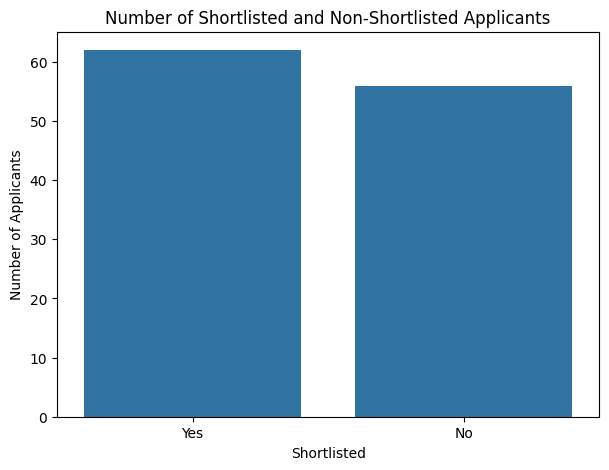

In [22]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="shortlisted")

plt.title("Number of Shortlisted and Non-Shortlisted Applicants")
plt.xlabel("Shortlisted")
plt.ylabel("Number of Applicants")

plt.show()

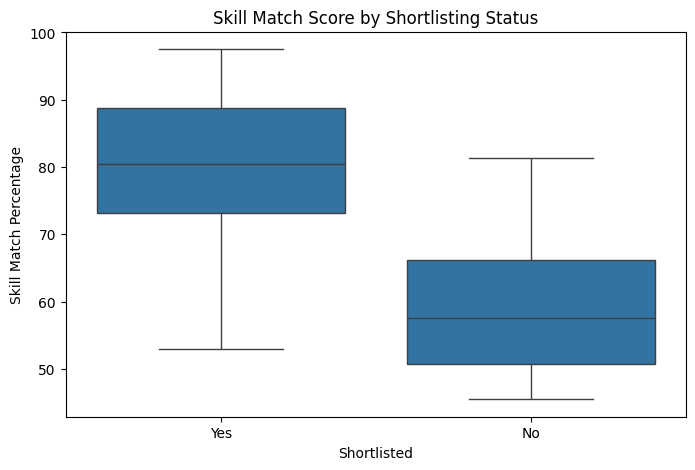

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="shortlisted",
    y="skill_match_percentage"
)

plt.title("Skill Match Score by Shortlisting Status")
plt.xlabel("Shortlisted")
plt.ylabel("Skill Match Percentage")

plt.show()

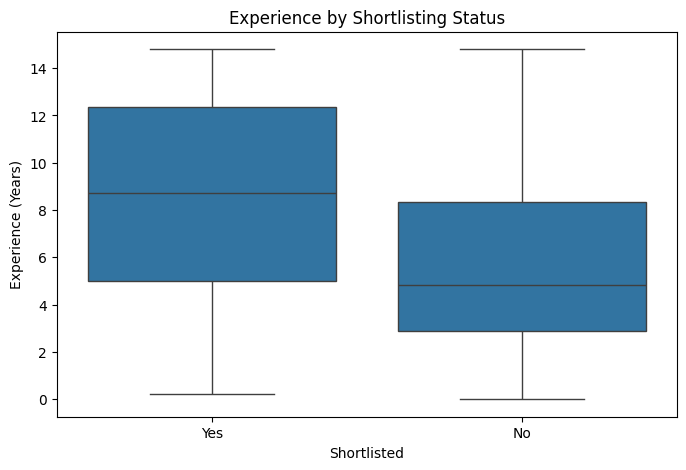

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="shortlisted",
    y="experience_years"
)

plt.title("Experience by Shortlisting Status")
plt.xlabel("Shortlisted")
plt.ylabel("Experience (Years)")

plt.show()

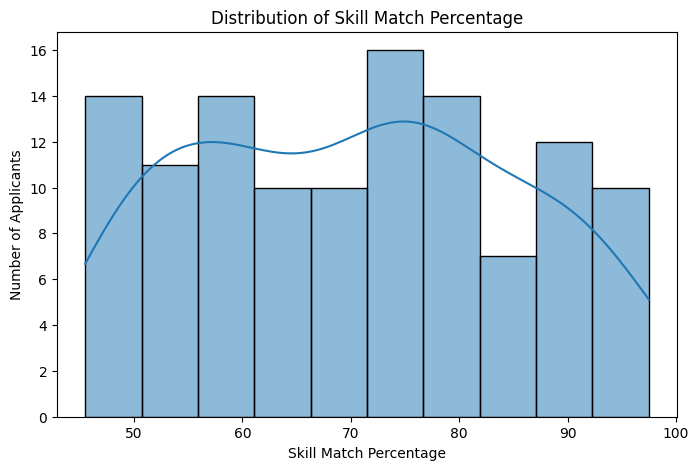

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="skill_match_percentage",
    bins=10,
    kde=True
)

plt.title("Distribution of Skill Match Percentage")
plt.xlabel("Skill Match Percentage")
plt.ylabel("Number of Applicants")

plt.show()

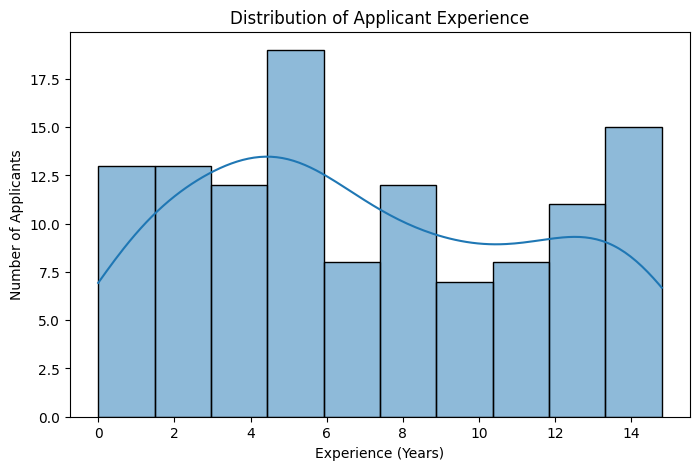

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="experience_years",
    bins=10,
    kde=True
)

plt.title("Distribution of Applicant Experience")
plt.xlabel("Experience (Years)")
plt.ylabel("Number of Applicants")

plt.show()

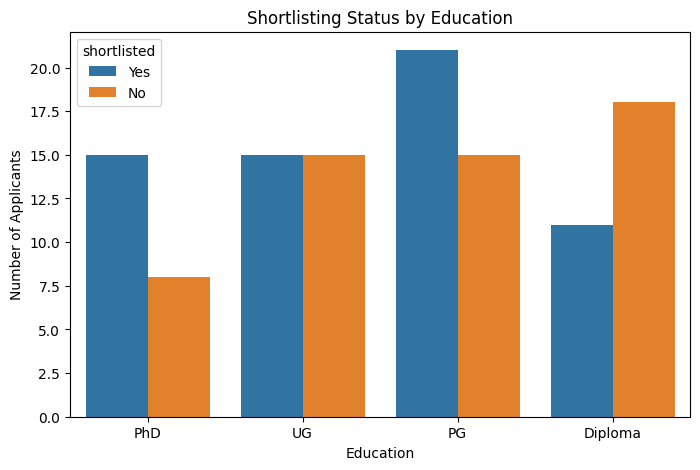

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="education",
    hue="shortlisted"
)

plt.title("Shortlisting Status by Education")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")

plt.show()

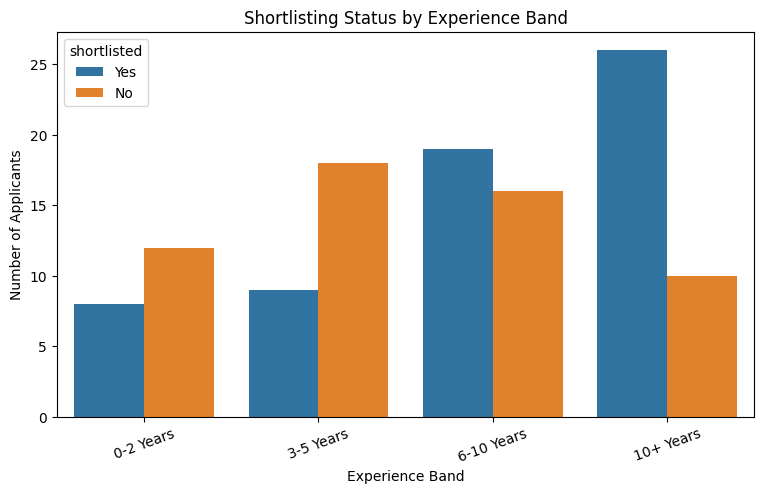

In [28]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="experience_band",
    hue="shortlisted"
)

plt.title("Shortlisting Status by Experience Band")
plt.xlabel("Experience Band")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=20)

plt.show()

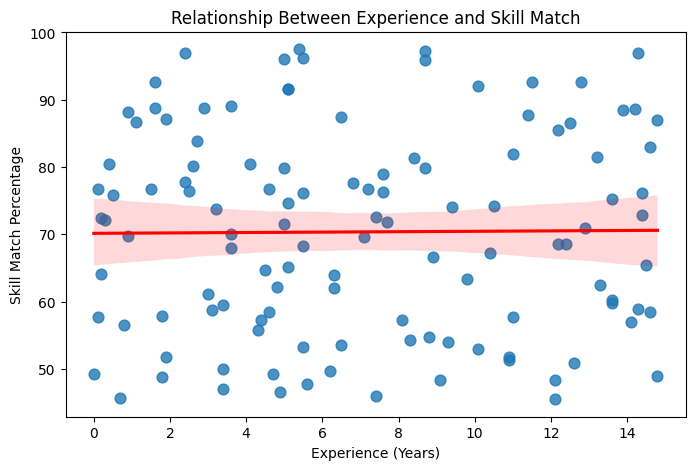

In [29]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="experience_years",
    y="skill_match_percentage",
    scatter_kws={"s": 60},
    line_kws={"color": "red"}
)

plt.title("Relationship Between Experience and Skill Match")
plt.xlabel("Experience (Years)")
plt.ylabel("Skill Match Percentage")

plt.show()

In [21]:
print("========== RECRUITMENT ANALYSIS SUMMARY ==========")

# Overall shortlisting rate
overall_rate = df["shortlisted_numeric"].mean() * 100

print("\nOverall Shortlisting Rate:",
      round(overall_rate, 2), "%")

# Best experience band
best_experience = experience_rate.idxmax()
best_experience_rate = experience_rate.max()

print("\nHighest Shortlisting Experience Band:",
      best_experience)

print("Shortlisting Rate:",
      round(best_experience_rate, 2), "%")

# Best education
best_education = education_rate.idxmax()
best_education_rate = education_rate.max()

print("\nHighest Shortlisting Education:",
      best_education)

print("Shortlisting Rate:",
      round(best_education_rate, 2), "%")

# Best skill band
best_skill = skill_rate.idxmax()
best_skill_rate = skill_rate.max()

print("\nHighest Shortlisting Skill Band:",
      best_skill)

print("Shortlisting Rate:",
      round(best_skill_rate, 2), "%")

========== RECRUITMENT ANALYSIS SUMMARY ==========

Overall Shortlisting Rate: 52.54 %

Highest Shortlisting Experience Band: 10+ Years
Shortlisting Rate: 72.22 %

Highest Shortlisting Education: PhD
Shortlisting Rate: 65.22 %

Highest Shortlisting Skill Band: 86-100%
Shortlisting Rate: 100.0 %


In [30]:
df.to_csv("cleaned_recruitment.csv", index=False)